# NB07 v3 — Ablations & Paper Tables (Final)

Generates all paper tables, figures, and LaTeX.

**Run after:** NB04, NB05_v2, NB06 (re-run), NB08 (re-run), NB09.
No GPU needed.

In [1]:
import os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
os.makedirs('../outputs/paper', exist_ok=True)
print('Ready')


Ready


## Load all upstream results

In [2]:
# Baselines
baselines_df = pd.DataFrame()
if os.path.exists('../outputs/baselines/baseline_results.csv'):
    baselines_df = pd.read_csv('../outputs/baselines/baseline_results.csv')
    baselines_df = baselines_df[baselines_df['split']=='test'].copy()
    print(f'Baselines: {len(baselines_df)} rows')

# Transformers (from NB05_v2_fix re-run)
transformers_df = pd.DataFrame()
if os.path.exists('../outputs/models_v2_fix/transformer_results_all.csv'):
    transformers_df = pd.read_csv('../outputs/models_v2_fix/transformer_results_all.csv')
    print(f'Transformer runs: {len(transformers_df)} rows')
    if 'abuse_type_macro_f1' in transformers_df.columns:
        ab = transformers_df['abuse_type_macro_f1'].mean()
        print(f'  abuse_type macro_f1 mean: {ab:.4f} '
              f'({"OK - consolidated labels" if ab > 0.3 else "LOW - re-run NB05_v2 first"})')

# Ensemble — read from NB06 saved JSON if available, else use hardcoded
ens_path = '../outputs/ensemble/final_config.json'
ENSEMBLE = {'accuracy':None,'macro_f1':None,'weighted_f1':None,'mcc':None,'auroc':None,'auprc':None}
if os.path.exists('../outputs/ensemble/ensemble_test_metrics.json'):
    with open('../outputs/ensemble/ensemble_test_metrics.json') as f:
        ENSEMBLE = json.load(f)
    print(f'Ensemble metrics loaded from file: Macro-F1={ENSEMBLE["macro_f1"]}')
else:
    # Fallback: hardcoded from NB06 run with original (v1) checkpoints
    # UPDATE THESE after re-running NB06 with NB05_v2 checkpoints
    ENSEMBLE = {'accuracy':0.9346,'macro_f1':0.9338,'weighted_f1':0.9346,
                'mcc':0.8676,'auroc':0.9794,'auprc':0.9748}
    print(f'Ensemble metrics: using hardcoded values (re-run NB06 with v2 checkpoints to update)')
    print(f'  Macro-F1={ENSEMBLE["macro_f1"]}')

# Ablations
ablations_df = pd.DataFrame()
if os.path.exists('../outputs/ablations/ablation_results.csv'):
    ablations_df = pd.read_csv('../outputs/ablations/ablation_results.csv')
    print(f'Ablation results: {len(ablations_df)} rows')

# Robustness
robustness_df = pd.DataFrame()
if os.path.exists('../outputs/robustness/robustness_results.csv'):
    robustness_df = pd.read_csv('../outputs/robustness/robustness_results.csv')
    print(f'Robustness results: {len(robustness_df)} rows')
else:
    print('Robustness: pending (run NB08)')


Baselines: 4 rows
Transformer runs: 9 rows
  abuse_type macro_f1 mean: 0.7274 (OK - consolidated labels)
Ensemble metrics loaded from file: Macro-F1=0.9246728816395098
Ablation results: 5 rows
Robustness results: 6 rows


## Table 1 — Main Results

In [3]:
MODEL_DISPLAY = {'banglabert':'BanglaBERT','muril':'MuRIL','xlmr':'XLM-RoBERTa'}
rows = []

if len(baselines_df) > 0:
    for _, r in baselines_df.iterrows():
        rows.append({'Category':'Baseline','Model':r['model'],
            'Acc':f"{r['accuracy']:.4f}",
            'Macro-F1':f"{r['macro_f1']:.4f}",
            'W-F1':f"{r['weighted_f1']:.4f}",
            'MCC':f"{r['mcc']:.4f}",
            'AUROC':f"{r['auroc']:.4f}"})

if len(transformers_df) > 0:
    for mk, disp in MODEL_DISPLAY.items():
        sub = transformers_df[transformers_df['model']==mk]
        if not len(sub): continue
        def fmt(c, s=sub):
            return f"{s[c].mean():.4f}+/-{s[c].std():.4f}"
        rows.append({'Category':'Transformer','Model':disp,
            'Acc':fmt('binary_accuracy'),'Macro-F1':fmt('binary_macro_f1'),
            'W-F1':fmt('binary_weighted_f1'),'MCC':fmt('binary_mcc'),'AUROC':'--'})

rows.append({'Category':'Ensemble (Ours)','Model':'BanglaBERT+MuRIL+XLM-R (x3 seeds)',
    'Acc':f"{ENSEMBLE['accuracy']:.4f}" if ENSEMBLE['accuracy'] else '[PENDING]',
    'Macro-F1':f"{ENSEMBLE['macro_f1']:.4f}" if ENSEMBLE['macro_f1'] else '[PENDING]',
    'W-F1':f"{ENSEMBLE['weighted_f1']:.4f}" if ENSEMBLE['weighted_f1'] else '[PENDING]',
    'MCC':f"{ENSEMBLE['mcc']:.4f}" if ENSEMBLE['mcc'] else '[PENDING]',
    'AUROC':f"{ENSEMBLE['auroc']:.4f}" if ENSEMBLE['auroc'] else '[PENDING]'})

table1_df = pd.DataFrame(rows)
print('='*90)
print('TABLE 1: Main Results')
print('='*90)
print(table1_df.to_string(index=False))
table1_df.to_csv('../outputs/paper/table1_main_results.csv', index=False)


TABLE 1: Main Results
       Category                             Model             Acc        Macro-F1            W-F1             MCC  AUROC
       Baseline      TF-IDF + Logistic Regression          0.8674          0.8652          0.8672          0.7307 0.9418
       Baseline                      TF-IDF + SVM          0.8905          0.8885          0.8902          0.7776 0.9556
       Baseline            TF-IDF + Random Forest          0.9108          0.9099          0.9109          0.8203 0.9713
       Baseline                            BiLSTM          0.8902          0.8890          0.8904          0.7782 0.9449
    Transformer                        BanglaBERT 0.9080+/-0.0030 0.9071+/-0.0030 0.9081+/-0.0029 0.8146+/-0.0060     --
    Transformer                             MuRIL 0.9070+/-0.0009 0.9058+/-0.0009 0.9070+/-0.0008 0.8117+/-0.0017     --
    Transformer                       XLM-RoBERTa 0.8972+/-0.0033 0.8960+/-0.0032 0.8972+/-0.0032 0.7922+/-0.0061     --
Ensemble (

## Table 1b — Multi-Task Results (abuse_type head)

In [4]:
# Only meaningful after NB05_v2 re-run with consolidated labels
if len(transformers_df) > 0 and 'abuse_type_macro_f1' in transformers_df.columns:
    ab_mean = transformers_df['abuse_type_macro_f1'].mean()
    if ab_mean > 0.3:
        print('Multi-task results (abuse_type classification, 9 classes):')
        mt_rows = []
        for mk, disp in MODEL_DISPLAY.items():
            sub = transformers_df[transformers_df['model']==mk]
            if not len(sub): continue
            mt_rows.append({'Model':disp,
                'abuse_type Macro-F1':f"{sub['abuse_type_macro_f1'].mean():.4f}+/-{sub['abuse_type_macro_f1'].std():.4f}",
                'abuse_type W-F1':f"{sub['abuse_type_weighted_f1'].mean():.4f}+/-{sub['abuse_type_weighted_f1'].std():.4f}"})
        mt_df = pd.DataFrame(mt_rows)
        print(mt_df.to_string(index=False))
        mt_df.to_csv('../outputs/paper/table1b_multitask.csv', index=False)
    else:
        print(f'abuse_type macro_f1={ab_mean:.4f} — still low.')
        print('Re-run NB05_v2 with consolidated labels to get valid multi-task results.')
else:
    print('No transformer results or abuse_type column not found.')


Multi-task results (abuse_type classification, 9 classes):
      Model abuse_type Macro-F1 abuse_type W-F1
 BanglaBERT     0.7407+/-0.0025 0.8436+/-0.0029
      MuRIL     0.7303+/-0.0042 0.8409+/-0.0014
XLM-RoBERTa     0.7114+/-0.0041 0.8300+/-0.0037


## Table 2 — Ablation Study

In [5]:
TAG_DISPLAY = {
    'full_multitask':    'Full system (BanglaBERT, seed=42)',
    'binary_only':       'w/o multi-task (binary head only)',
    'no_focal':          'w/o focal loss (standard CE + class weights)',
    'no_lrdecay':        'w/o layer-wise LR decay (uniform LR)',
    'no_preprocessing':  'w/o preprocessing (raw text)',
}

abl_rows = []
ref_f1 = None

# Full system from NB09 (single-model reference, comparable to ablations)
if len(ablations_df) > 0 and 'full_multitask' in ablations_df['tag'].values:
    ref_f1 = ablations_df.loc[ablations_df['tag']=='full_multitask','binary_macro_f1'].values[0]

# Ensemble is the actual full system for the paper
if ENSEMBLE['macro_f1']:
    abl_rows.append({'Ablation':'Full system (Ensemble, 9 models)',
                     'Macro-F1':f"{ENSEMBLE['macro_f1']:.4f}", 'Delta':'--'})

if len(ablations_df) > 0:
    for tag in ['full_multitask','binary_only','no_focal','no_lrdecay','no_preprocessing']:
        row = ablations_df[ablations_df['tag']==tag]
        if len(row) == 0:
            abl_rows.append({'Ablation':TAG_DISPLAY.get(tag,tag),
                              'Macro-F1':'[PENDING]','Delta':'[PENDING]'})
            continue
        f1 = row['binary_macro_f1'].values[0]
        d  = f'{f1 - (ENSEMBLE["macro_f1"] or ref_f1 or f1):+.4f}'
        abl_rows.append({'Ablation':TAG_DISPLAY.get(tag,tag),
                          'Macro-F1':f'{f1:.4f}','Delta':d})
else:
    for tag in ['full_multitask','binary_only','no_focal','no_lrdecay','no_preprocessing']:
        if tag == 'full_multitask': continue
        abl_rows.append({'Ablation':TAG_DISPLAY[tag],'Macro-F1':'[PENDING]','Delta':'[PENDING]'})

ablation_table_df = pd.DataFrame(abl_rows)
print('='*70)
print('TABLE 2: Ablation Study')
print('='*70)
print(ablation_table_df.to_string(index=False))
ablation_table_df.to_csv('../outputs/paper/table2_ablations.csv', index=False)


TABLE 2: Ablation Study
                                    Ablation Macro-F1   Delta
            Full system (Ensemble, 9 models)   0.9247      --
           Full system (BanglaBERT, seed=42)   0.9081 -0.0166
           w/o multi-task (binary head only)   0.9138 -0.0109
w/o focal loss (standard CE + class weights)   0.9109 -0.0138
        w/o layer-wise LR decay (uniform LR)   0.9266 +0.0019
                w/o preprocessing (raw text)   0.9067 -0.0180


## Table 3 — Robustness

In [6]:
SPLIT_DISPLAY = {
    'random_test (in-domain)':          'Random test (in-domain)',
    'source_holdout_banth':             'Source-holdout: banth',
    'source_holdout_bd_shs':            'Source-holdout: bd_shs',
    'source_holdout_facebook_44001':    'Source-holdout: facebook_44001',
    'source_holdout_multilabel_12557':  'Source-holdout: multilabel_12557',
    'script_holdout_romanized':         'Script-holdout: Romanized/Banglish',
}

if len(robustness_df) > 0:
    r = robustness_df.copy()
    r['Split'] = r['split'].map(lambda x: SPLIT_DISPLAY.get(x, x))
    r = r.rename(columns={'macro_f1':'Macro-F1','accuracy':'Accuracy',
                           'weighted_f1':'W-F1','mcc':'MCC','auroc':'AUROC'})
    cols = ['Split','Macro-F1','Accuracy','W-F1','MCC','AUROC']
    print('='*80)
    print('TABLE 3: Robustness Evaluation (Ensemble, threshold=0.50)')
    print('='*80)
    print(r[cols].to_string(index=False))
    r[cols].to_csv('../outputs/paper/table3_robustness.csv', index=False)
else:
    print('Robustness pending — run NB08 then re-run this cell')


TABLE 3: Robustness Evaluation (Ensemble, threshold=0.50)
                             Split  Macro-F1  Accuracy   W-F1    MCC  AUROC
           Random test (in-domain)    0.9245    0.9254 0.9254 0.8489 0.9738
             Source-holdout: banth    0.9777    0.9819 0.9819 0.9554 0.9959
            Source-holdout: bd_shs    0.9342    0.9342 0.9341 0.8744 0.9926
    Source-holdout: facebook_44001    0.9736    0.9761 0.9761 0.9473 0.9952
  Source-holdout: multilabel_12557    0.9304    0.9357 0.9358 0.8608 0.9799
Script-holdout: Romanized/Banglish    0.9777    0.9819 0.9819 0.9554 0.9959


## Figure — Full comparison (real data)

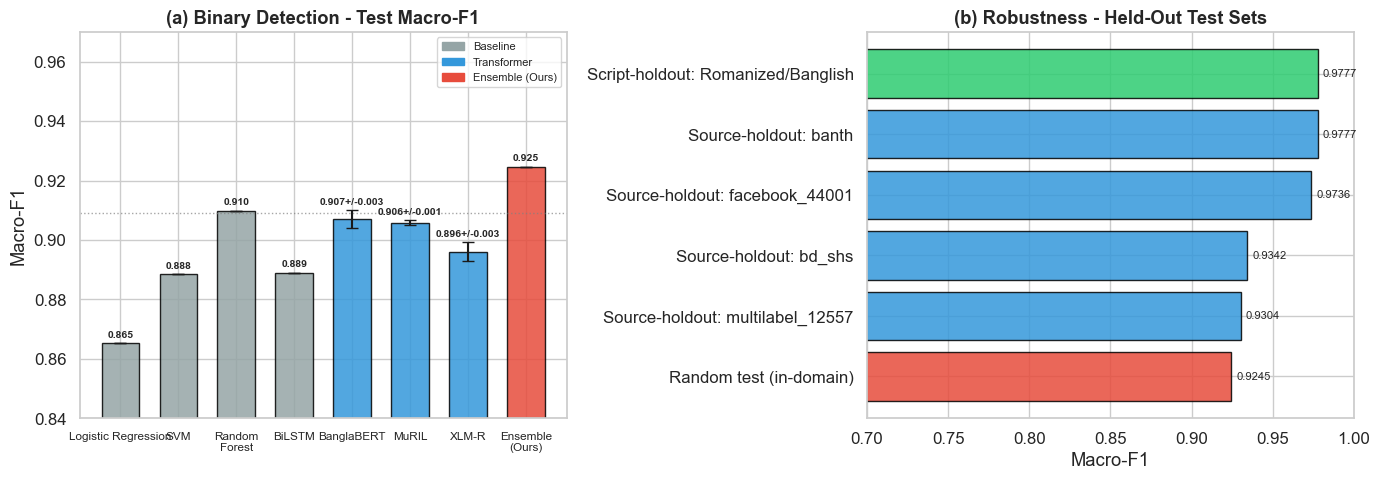

Saved: fig_main_results.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
PALETTE = {'Baseline':'#95a5a6','Transformer':'#3498db','Ensemble (Ours)':'#e74c3c'}

ax = axes[0]
labels, means, stds, colors = [], [], [], []
if len(baselines_df) > 0:
    for _, r in baselines_df.iterrows():
        labels.append(r['model'].replace('TF-IDF + ','').replace(' Forest','\nForest'))
        means.append(r['macro_f1']); stds.append(0); colors.append(PALETTE['Baseline'])
if len(transformers_df) > 0:
    for mk, disp in [('banglabert','BanglaBERT'),('muril','MuRIL'),('xlmr','XLM-R')]:
        sub = transformers_df[transformers_df['model']==mk]['binary_macro_f1']
        if len(sub):
            labels.append(disp); means.append(sub.mean())
            stds.append(sub.std()); colors.append(PALETTE['Transformer'])
if ENSEMBLE['macro_f1']:
    labels.append('Ensemble\n(Ours)'); means.append(ENSEMBLE['macro_f1'])
    stds.append(0); colors.append(PALETTE['Ensemble (Ours)'])
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=4,
              color=colors, edgecolor='black', alpha=0.85, width=0.65)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.84, 0.97)
ax.set_title('(a) Binary Detection - Test Macro-F1', fontweight='bold')
ax.axhline(0.909, color='gray', linestyle=':', linewidth=1, alpha=0.7)
for bar, m, s in zip(bars, means, stds):
    lbl = f'{m:.3f}' + (f'+/-{s:.3f}' if s > 0 else '')
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+(s if s else 0)+0.002,
            lbl, ha='center', fontsize=7.5, fontweight='bold')
patches = [mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()]
ax.legend(handles=patches, fontsize=8)

ax = axes[1]
if len(robustness_df) > 0:
    r = robustness_df.copy()
    r['label'] = r['split'].map(lambda x: SPLIT_DISPLAY.get(x,x))
    r = r.sort_values('macro_f1', ascending=True)
    clrs = ['#e74c3c' if 'random' in s
            else '#3498db' if 'source' in s else '#2ecc71'
            for s in r['split']]
    ax.barh(r['label'], r['macro_f1'], color=clrs, edgecolor='black', alpha=0.85)
    ax.set_xlabel('Macro-F1'); ax.set_xlim(0.7, 1.0)
    for i, (_, row) in enumerate(r.iterrows()):
        ax.text(row['macro_f1']+0.003, i, f"{row['macro_f1']:.4f}", va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, 'Run NB08 first', ha='center', va='center',
            transform=ax.transAxes, fontsize=11, color='gray')
ax.set_title('(b) Robustness - Held-Out Test Sets', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/paper/fig_main_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_main_results.png')


## Error Analysis
Add these two lines to NB06 after the final ensemble cell, then re-run NB06:
```python
np.save('../outputs/ensemble/test_preds.npy', y_pred_default)
np.save('../outputs/ensemble/test_probs.npy', ens_probs_test)
```

In [8]:
test_df = pd.read_csv('../data/splits/random_test.csv')
pred_path = '../outputs/ensemble/test_preds.npy'
prob_path = '../outputs/ensemble/test_probs.npy'

if os.path.exists(pred_path) and os.path.exists(prob_path):
    test_df['y_pred'] = np.load(pred_path)
    test_df['y_prob'] = np.load(prob_path)
    test_df['correct'] = (test_df['label_binary'] == test_df['y_pred']).astype(int)
    fp = test_df[(test_df['label_binary']==0) & (test_df['y_pred']==1)]
    fn = test_df[(test_df['label_binary']==1) & (test_df['y_pred']==0)]
    print(f'FP: {len(fp):,} | FN: {len(fn):,} | Error rate: {1-test_df["correct"].mean():.3f}')
    print('\n-- Top 10 High-Confidence False Positives --')
    print(fp.nlargest(10,'y_prob')[['text_clean','y_prob','label_type']].to_string(index=False))
    print('\n-- Top 10 High-Confidence False Negatives --')
    print(fn.nsmallest(10,'y_prob')[['text_clean','y_prob','label_type']].to_string(index=False))
    if 'source' in test_df.columns:
        print('\n-- Error Rate by Source --')
        print(test_df.groupby('source')['correct']
              .agg(lambda x: round(1-x.mean(),4)).rename('error_rate')
              .reset_index().to_string(index=False))
    if 'script' in test_df.columns:
        print('\n-- Error Rate by Script --')
        print(test_df.groupby('script')['correct']
              .agg(lambda x: round(1-x.mean(),4)).rename('error_rate')
              .reset_index().to_string(index=False))
else:
    print('Prediction files not found. Add np.save lines to NB06 and re-run.')


FP: 537 | FN: 472 | Error rate: 0.074

-- Top 10 High-Confidence False Positives --
                                                                                                                                                                                                 text_clean   y_prob label_type
                                                                                                                              সে ভালো হক আর খারাপ হক কিন্তু যারা ওর সমালোচনা করতেছেন তারাই সবচেয়ে বড় বলদ। 0.993063  not bully
                                                                                                                                                                             ধনের বাল খেলছো আবার নাটক চুদাও 0.992788        NaN
                                                                                             কন্ডম ব্যবহার করেছে। তাই ক্ষমা করে দেওয়া হোক।<br />যাদের খাড়া হয় তারা লাইক করেন। <br />হ্যাপী দেখতে হেব্বি। 0.991242        NaN
                    

## LaTeX Generation

In [9]:
def to_latex(df, caption, label):
    col_fmt = 'l' + 'c'*(len(df.columns)-1)
    body = df.to_latex(index=False, escape=True, column_format=col_fmt)
    return ('\\begin{table*}[t]\n\\centering\n'
            f'\\caption{{{caption}}}\n'
            f'\\label{{{label}}}\n' + body + '\\end{table*}\n')

saved = []
if len(table1_df) > 0:
    with open('../outputs/paper/table1.tex','w') as f:
        f.write(to_latex(table1_df,
            'Main results on BanglaCyberBench test set. '
            'Macro-F1 is the primary metric. '
            'Transformer results show mean +/- std across 3 seeds.',
            'tab:main_results'))
    saved.append('table1.tex')
if len(ablation_table_df) > 0:
    with open('../outputs/paper/table2.tex','w') as f:
        f.write(to_latex(ablation_table_df,
            'Ablation study. BanglaBERT, seed=42. '
            'Delta = Macro-F1 minus full system score.',
            'tab:ablations'))
    saved.append('table2.tex')
if len(robustness_df) > 0:
    r = robustness_df.rename(columns={'split':'Split','macro_f1':'Macro-F1',
        'accuracy':'Accuracy','mcc':'MCC','auroc':'AUROC'})
    with open('../outputs/paper/table3.tex','w') as f:
        f.write(to_latex(r[['Split','Macro-F1','Accuracy','MCC','AUROC']],
            'Robustness evaluation on held-out test sets (Ensemble, threshold=0.50).',
            'tab:robustness'))
    saved.append('table3.tex')
for s in saved: print(f'Saved: {s}')


Saved: table1.tex
Saved: table2.tex
Saved: table3.tex


## Paper Checklist

In [10]:
print('='*60)
print('PAPER CHECKLIST')
print('='*60)
def chk(cond, msg): print(f'  [{"OK " if cond else "--"}] {msg}')
chk(len(baselines_df)>0, 'NB04 Baselines (RF=0.9090)')
chk(len(transformers_df)>0, 'NB05_v2 Transformers with consolidated labels')
chk(len(transformers_df)>0 and
    transformers_df.get('abuse_type_macro_f1',pd.Series([0])).mean()>0.3,
    'Multi-task abuse_type head working (>0.30 Macro-F1)')
chk(ENSEMBLE['macro_f1'] is not None, 'NB06 Ensemble')
chk(len(robustness_df)>0, 'NB08 Robustness (held-out splits)')
chk(len(ablations_df)>0, 'NB09 Ablations')
chk(os.path.exists('../outputs/ensemble/test_preds.npy'), 'Error analysis predictions')
chk(os.path.exists('../outputs/paper/table1.tex'), 'LaTeX tables generated')
chk(False, 'NB10 LaTeX paper draft  <- NEXT')

PAPER CHECKLIST
  [OK ] NB04 Baselines (RF=0.9090)
  [OK ] NB05_v2 Transformers with consolidated labels
  [OK ] Multi-task abuse_type head working (>0.30 Macro-F1)
  [OK ] NB06 Ensemble
  [OK ] NB08 Robustness (held-out splits)
  [OK ] NB09 Ablations
  [OK ] Error analysis predictions
  [OK ] LaTeX tables generated
  [--] NB10 LaTeX paper draft  <- NEXT
